# Evaluate the Alignment Algorithm on Real Piano Performances

This notebook evaluates the edit-distance (ED) alignment algorithm in `compareMusic` on real piano performances from the [(n)ASAP dataset](https://github.com/CPJKU/asap-dataset) (Peter, 2023).

(n)ASAP is a dataset of aligned musical scores and performances built by extending the ASAP dataset with note-level annotations. The ASAP contains 236 distinct musical scores and 1067 performances of Western classical piano music from 15 different composers, the piece directory contains the XML and MIDI score, plus all of the performances of a specific piece, including: 
- `midi_score`: the MIDI score (what should be played) — used as **reference**
- `midi_performance`: what the pianist actually played — used as **response**
- `note_alignments.tsv`: official note-level alignment annotations — used as **ground truth**

bib citation:

@article{Peter-2023,
 title = {Automatic Note-Level Score-to-Performance Alignments in the ASAP Dataset},
 author = {Peter, Silvan David and Cancino-Chacón, Carlos Eduardo and Foscarin, Francesco and McLeod, Andrew Philip and Henkel, Florian and Karystinaios, Emmanouil and Widmer, Gerhard},
 doi = {10.5334/tismir.149},
 journal = {Transactions of the International Society for Music Information Retrieval {(TISMIR)}},
 year = {2023}
}

relevant paper: https://transactions.ismir.net/articles/10.5334/tismir.149#5-alignment-of-the-asap-dataset

## Download the (n)ASAP Dataset

In [3]:
import os

# Note: use CPJKU version (not fosfrancesco) because only CPJKU has
# the note_alignments TSV files are needed for ground truth comparison.
if not os.path.exists("asap-dataset"):
    os.system("git clone https://github.com/CPJKU/asap-dataset.git")
else:
    print("asap-dataset already exists, skipping download.")

ASAP_PATH = "asap-dataset"

asap-dataset already exists, skipping download.


## Load the Ground Truth (GT)

The `note_alignment.tsv` file in each performance contains the official note-level alignment annotations. Each row represents one note, with columns: `xml_id`, `midi_id`, `track`, `channel`, `pitch`, `onset`.
- If `midi_id == "deletion"`: the score note was not played → label `deletion`
- If `xml_id == "insertion"`: an extra note was played → label `insertion`
- Otherwise: a matched pair → label `paired`

For `match` and `insertion` rows, the TSV provides `onset` (onset time in seconds) and `pitch` (MIDI pitch) for the performance note.

In [4]:
import csv

def load_ground_truth(tsv_path):
    rows = []

    with open(tsv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")

        for row in reader:
            xml_id = row["xml_id"].strip()
            midi_id = row["midi_id"].strip()

            if midi_id == "deletion":
                rows.append({
                    "label": "deletion",
                    "xml_id": xml_id,
                    "midi_id": None,
                    "onset": None,
                    "pitch": None,
                })

            elif xml_id == "insertion":
                rows.append({
                    "label": "insertion",
                    "xml_id": None,
                    "midi_id": midi_id,
                    "onset": float(row["onset"]),
                    "pitch": int(row["pitch"]),
                })

            else:
                rows.append({
                    "label": "paired",
                    "xml_id": xml_id,
                    "midi_id": midi_id,
                    "onset": float(row["onset"]),
                    "pitch": int(row["pitch"]),
                })

    return rows

## Load Score (reference)/Performance (response) pairs

Helper functions for format conversion: These functions convert a MIDI file into the `{pitch, start, duration}` format used by `compare_MIDI.py`.

In [5]:
import pretty_midi

def midi_file_to_notes(midi_path):
    """Parse a MIDI file into the format used by compareMusic."""
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    all_notes = []

    for instrument in midi_data.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            all_notes.append({
                "pitch": int(note.pitch),
                # Keep full precision. Rounding here can change tolerance-based
                # evaluation close to the matching boundary.
                "start": float(note.start),
                "duration": float(note.end - note.start),
            })

    all_notes.sort(key=lambda note: (note["start"], note["pitch"]))
    return all_notes

def build_sample(ref_path, response_path, composer, title, metadata_row):
    """Build one score/performance sample for compare_performance_ED."""
    score_notes = midi_file_to_notes(ref_path)
    performance_notes = midi_file_to_notes(response_path)

    if not score_notes or not performance_notes:
        return None

    return {
        "composer": composer,
        "title": title,
        "reference": {"notes": score_notes},
        "response": {"notes": performance_notes},
        "metadata_row": metadata_row,
    }

For the (n)ASAP dataset, the `metadata.csv` lists every score/performance pair in the dataset, check that both MIDI files exist on disk.

In [6]:
def load_samples(asap_path, composer):
    """
    Read the ASAP metadata CSV and return a list of sample dicts
    for a specific composer only.

    Args:
        asap_path: str, path to the cloned ASAP repo
        composer: str, e.g. "Bach"

    Returns:
        list of sample dicts (see build_sample)
    """
    metadata_path = os.path.join(asap_path, "metadata.csv")
    samples = []

    with open(metadata_path, "r", encoding="utf-8") as csv_file:
        reader = csv.DictReader(csv_file)
        for row in reader:
            if row.get("composer", "").strip() == composer:
                ref_path = os.path.join(asap_path, row.get("midi_score", "").strip())
                response_path = os.path.join(asap_path, row.get("midi_performance", "").strip())

                if os.path.isfile(ref_path) and os.path.isfile(response_path):
                    sample = build_sample(
                        ref_path, response_path,
                        row.get("composer", "Unknown"),
                        row.get("title", "Unknown"),
                        dict(row),
                    )
                    if sample is not None:
                        samples.append(sample)

    return samples

samples = load_samples(ASAP_PATH, "Bach")

print("Loaded", len(samples), "score (reference) /performance (response) pairs.")

/Users/jz7125/compareMusic/.venv/lib/python3.13/site-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Loaded 169 score (reference) /performance (response) pairs.


# Run Alignment on Each Pair

Each score/performance pair is passed through `compare_performance_ED`. The current pipeline normalises the first onset to zero and groups nearby notes into events. Because `event_details` stores event indices, the same normalisation and grouping steps are reproduced here tso that the correct onset and pitch for each event during ground truth comparison can be looked up.

The original response onset offset is retained and added back only during comparison with the absolute performance times in the TSV file.

In [7]:
from evaluation_function.compare_MIDI import (
    compare_performance_ED,
    normalize_start_times,
    group_notes_into_events,
)

def run_alignment_on_samples(samples):
    """Run compare_performance_ED for every loaded sample."""
    results = []

    for sample in samples:
        result = compare_performance_ED(sample["response"], sample["reference"])

        response_notes_normalized = normalize_start_times(
            sample["response"]["notes"]
        )
        response_events_normalized = group_notes_into_events(
            response_notes_normalized
        )

        # Also rebuild the normalized reference events. convert_pipeline_output
        # needs these to look up how many notes are in a missing (deleted)
        # chord, since the pipeline's event_details does not carry that
        # information for missing/extra events.
        ref_notes_normalized = normalize_start_times(
            sample["reference"]["notes"]
        )
        ref_events_normalized = group_notes_into_events(
            ref_notes_normalized
        )

        response_onset_offset = float(sample["response"]["notes"][0]["start"])

        results.append({
            "composer": sample["composer"],
            "title": sample["title"],
            "stats": result.stats,
            "event_details": result.event_details,
            "is_correct": result.is_correct,
            "response_events_normalized": response_events_normalized,
            "ref_events_normalized": ref_events_normalized,
            "response_onset_offset": response_onset_offset,
        })

    return results

all_results = run_alignment_on_samples(samples)
print("Alignment complete for", len(all_results), "pieces.")

Alignment complete for 169 pieces.


## Compute Precision, Recall, and F1 

**Pipeline output vs ground truth**

he GT has three different labels, while our pipeline has four operations:

| Pipeline operation | GT label | Explanation |
|---|---|---|
| `match` | `paired` | Same pitch — GT still calls this `paired` |
| `replacement` | `paired` | Different pitch — GT still calls this `paired`, because the score note *was* played at approximately the right time |
| `missing` | `deletion` | Score note not found in response |
| `extra` | `insertion` | Response note has no score counterpart |

**Evaluation metrics design**

Evaluation is performed at **note level** after expanding chord events. Matches are one-to-one, so three notes at the same chord onset remain three separate observations.

| Label | Matching key | TP | FP | FN |
|---|---|---|---|---|
| `paired` (pipeline `match` / `replacement`) | onset-only matching within `ONSET_TOLERANCE`; pitch is intentionally ignored because this evaluates alignment rather than pitch correctness| Pipeline and ground truth both contain a paired label at matching performance onsets within the tolerance | Pipeline predicts a pairing at this onset that the ground truth does not recognise | Ground truth expects a pairing at this onset that the pipeline fails to find |
| `deletion` (pipeline `missing`) | count only as no onset or pitch available for deletions | Overlap between the pipeline deletion count and the ground-truth deletion count | The pipeline predicts more deletions than appear in the ground truth; the excess count is treated as FP | The ground truth contains more deletions than the pipeline predicts; the missing count is treated as FN |
| `insertion` (pipeline `extra`) | pitch must be equal and onset must be within `ONSET_TOLERANCE` | Pipeline and ground truth agree an extra, unexpected note was played at this pitch and onset | Pipeline flags a note as extra that the ground truth does not agree with | Ground truth marks a note as extra that the pipeline fails to identify |

- Precision: TP / (TP + FP), i.e. of all labels the pipeline predicted, how many were correct  
- Recall: TP / (TP + FN), i.e. of all GT labels, how many the pipeline found  
- F1: the harmonic mean of precision and recall 

In [8]:
def convert_pipeline_output(event_details, response_events, ref_events):
    """
    Convert event-level alignment output into note-level alignment labels.

    Alignment labels describe note correspondence, not pitch correctness.

    Rules:
        missing:
            Every note in the reference event becomes a deletion.

        extra:
            Every note in the response event becomes an insertion.

        match/replacement:
            Pair as many response and reference notes as possible.
            Different pitches may still form a paired alignment.
            Remaining response notes become insertions.
            Remaining reference notes become deletions.

    This implementation guarantees:

        paired + insertion == total response notes

        paired + deletion == total reference notes
    """
    predictions = []

    for event in event_details:
        operation = event["operation_type"]

        response_event = None
        reference_event = None

        if event.get("response_index") is not None:
            response_index = event["response_index"] - 1

            if (
                response_index < 0
                or response_index >= len(response_events)
            ):
                raise IndexError(
                    "response_index is outside response_events"
                )

            response_event = response_events[response_index]

        if event.get("reference_index") is not None:
            reference_index = event["reference_index"] - 1

            if (
                reference_index < 0
                or reference_index >= len(ref_events)
            ):
                raise IndexError(
                    "reference_index is outside ref_events"
                )

            reference_event = ref_events[reference_index]

        # ----------------------------------------------------------
        # Entire reference event is missing.
        # ----------------------------------------------------------
        if operation == "missing":
            for reference_note in reference_event["notes"]:
                predictions.append({
                    "onset": None,
                    "pitch": None,
                    "label": "deletion",
                })

            continue

        # ----------------------------------------------------------
        # Entire response event is extra.
        # ----------------------------------------------------------
        if operation == "extra":
            for response_note in response_event["notes"]:
                predictions.append({
                    "onset": float(response_note["start"]),
                    "pitch": int(response_note["pitch"]),
                    "label": "insertion",
                })

            continue

        # ----------------------------------------------------------
        # Matched or replacement event.
        # ----------------------------------------------------------
        response_notes = sorted(
            response_event["notes"],
            key=lambda note: int(note["pitch"])
        )

        reference_notes = sorted(
            reference_event["notes"],
            key=lambda note: int(note["pitch"])
        )

        pair_count = min(
            len(response_notes),
            len(reference_notes)
        )

        # Pair notes positionally after sorting by pitch.
        #
        # A pitch difference does not change the alignment label:
        # it remains paired.
        for index in range(pair_count):
            response_note = response_notes[index]

            predictions.append({
                "onset": float(response_note["start"]),
                "pitch": int(response_note["pitch"]),
                "label": "paired",
            })

        # Response side contains more notes.
        for response_note in response_notes[pair_count:]:
            predictions.append({
                "onset": float(response_note["start"]),
                "pitch": int(response_note["pitch"]),
                "label": "insertion",
            })

        # Reference side contains more notes.
        missing_count = len(reference_notes) - pair_count

        for _ in range(missing_count):
            predictions.append({
                "onset": None,
                "pitch": None,
                "label": "deletion",
            })

    return predictions

In [9]:
ONSET_TOLERANCE = 0.05  # 50 milliseconds

def count_onset_matches(gt_onsets, predicted_onsets, tolerance):
    """Count one-to-one onset matches while preserving chord notes."""
    gt_onsets = sorted(gt_onsets)
    predicted_onsets = sorted(predicted_onsets)

    gt_index = 0
    predicted_index = 0
    matches = 0

    while gt_index < len(gt_onsets) and predicted_index < len(predicted_onsets):
        difference = predicted_onsets[predicted_index] - gt_onsets[gt_index]

        if abs(difference) <= tolerance:
            matches += 1
            gt_index += 1
            predicted_index += 1
        elif difference < -tolerance:
            predicted_index += 1
        else:
            gt_index += 1

    return matches

In [10]:
def compute_metrics(ground_truth, predictions, onset_offset=0.0):
    """Compute note-level precision, recall, and F1."""
    total_tp = 0
    total_fp = 0
    total_fn = 0

    # 1. Paired notes: compare onset only.
    gt_paired = [
        row["onset"]
        for row in ground_truth
        if row["label"] == "paired" and row["onset"] is not None
    ]
    predicted_paired = [
        row["onset"] + onset_offset
        for row in predictions
        if row["label"] == "paired" and row["onset"] is not None
    ]

    paired_tp = count_onset_matches(
        gt_paired, predicted_paired, ONSET_TOLERANCE
    )
    total_tp += paired_tp
    total_fp += len(predicted_paired) - paired_tp
    total_fn += len(gt_paired) - paired_tp

    # 2. Insertions: compare both pitch and onset.
    gt_insertions = {}
    predicted_insertions = {}

    for row in ground_truth:
        if (
            row["label"] == "insertion"
            and row["pitch"] is not None
            and row["onset"] is not None
        ):
            pitch = int(row["pitch"])
            if pitch not in gt_insertions:
                gt_insertions[pitch] = []
            gt_insertions[pitch].append(float(row["onset"]))

    for row in predictions:
        if (
            row["label"] == "insertion"
            and row["pitch"] is not None
            and row["onset"] is not None
        ):
            pitch = int(row["pitch"])
            if pitch not in predicted_insertions:
                predicted_insertions[pitch] = []
            predicted_insertions[pitch].append(
                float(row["onset"]) + onset_offset
            )

    for pitch in set(gt_insertions) | set(predicted_insertions):
        gt_onsets = gt_insertions.get(pitch, [])
        predicted_onsets = predicted_insertions.get(pitch, [])

        insertion_tp = count_onset_matches(
            gt_onsets,
            predicted_onsets,
            ONSET_TOLERANCE,
        )
        total_tp += insertion_tp
        total_fp += len(predicted_onsets) - insertion_tp
        total_fn += len(gt_onsets) - insertion_tp

    # 3. Deletions: count-based because the pipeline does not return xml_id.
    gt_deletions = sum(
        row["label"] == "deletion" for row in ground_truth
    )
    predicted_deletions = sum(
        row["label"] == "deletion" for row in predictions
    )

    deletion_tp = min(gt_deletions, predicted_deletions)
    total_tp += deletion_tp
    total_fp += predicted_deletions - deletion_tp
    total_fn += gt_deletions - deletion_tp

    precision = (
        total_tp / (total_tp + total_fp)
        if total_tp + total_fp > 0 else 0.0
    )
    recall = (
        total_tp / (total_tp + total_fn)
        if total_tp + total_fn > 0 else 0.0
    )
    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0 else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
    }

## Evaluate all pieces

The evaluation is note-level. Notes inside a chord are kept as separate notes. Paired notes use a 50 ms onset tolerance, while insertions require both the same MIDI pitch and a matching onset.

In [11]:
import pandas as pd

evaluation_rows = []

for sample, result in zip(samples, all_results):
    metadata_row = sample["metadata_row"]
    tsv_relative_path = (metadata_row.get("note_alignments") or "").strip()
    tsv_path = os.path.join(ASAP_PATH, tsv_relative_path)

    if not os.path.isfile(tsv_path):
        print("TSV not found:", tsv_path)
        continue

    ground_truth = load_ground_truth(tsv_path)
    predictions = convert_pipeline_output(
        result["event_details"],
        result["response_events_normalized"],
        result["ref_events_normalized"],
    )

    metrics = compute_metrics(
        ground_truth,
        predictions,
        onset_offset=result["response_onset_offset"],
    )

    evaluation_rows.append({
        "Piece": f'{result["composer"]} ({result["title"]})',
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "TP": metrics["tp"],
        "FP": metrics["fp"],
        "FN": metrics["fn"],
    })

df_eval = pd.DataFrame(evaluation_rows)
print(df_eval.sort_values("Precision", ascending=True).head(10).round(4))

print("Mean Precision:", round(df_eval["Precision"].mean(), 4))
print("Mean Recall   :", round(df_eval["Recall"].mean(), 4))
print("Mean F1       :", round(df_eval["F1"].mean(), 4))

                      Piece  Precision  Recall      F1    TP   FP   FN
153  Bach (Prelude_bwv_885)     0.8413  0.8866  0.8633   477   90   61
110  Bach (Prelude_bwv_858)     0.8456  0.9163  0.8795   449   82   41
109  Bach (Prelude_bwv_858)     0.8482  0.9710  0.9055   436   78   13
134  Bach (Prelude_bwv_874)     0.8578  0.9029  0.8798  1442  239  155
135  Bach (Prelude_bwv_874)     0.8628  0.9084  0.8850  1428  227  144
76     Bach (Fugue_bwv_889)     0.8667  0.8636  0.8651   741  114  117
73     Bach (Fugue_bwv_889)     0.8749  0.8759  0.8754   748  107  106
77     Bach (Fugue_bwv_889)     0.8751  0.8783  0.8767   736  105  102
102  Bach (Prelude_bwv_856)     0.8763  0.9914  0.9303   921  130    8
72     Bach (Fugue_bwv_889)     0.8796  0.8817  0.8806   745  102  100
Mean Precision: 0.9637
Mean Recall   : 0.9701
Mean F1       : 0.9668


### Interpretation of results

In [32]:
SELECTED_SAMPLE_INDEX = 153

selected_sample = samples[SELECTED_SAMPLE_INDEX]
selected_result = all_results[SELECTED_SAMPLE_INDEX]

ref_events = selected_result["ref_events_normalized"]
response_events = selected_result["response_events_normalized"]
event_details = selected_result["event_details"]

metadata_row = selected_sample["metadata_row"]

tsv_path = os.path.join(ASAP_PATH, metadata_row["note_alignments"].strip())
xml_path = os.path.join(ASAP_PATH, metadata_row["xml_score"].strip())
midi_score_path = os.path.join(ASAP_PATH, metadata_row["midi_score"].strip())
midi_performance_path = os.path.join(ASAP_PATH, metadata_row["midi_performance"].strip())

ground_truth = load_ground_truth(tsv_path)

predictions = convert_pipeline_output(
    selected_result["event_details"],
    selected_result["response_events_normalized"],
    selected_result["ref_events_normalized"],
)

# Add the original response onset offset back.
for prediction in predictions:
    if prediction["onset"] is not None:
        prediction["onset"] += selected_result["response_onset_offset"]

print("Piece:", selected_result["composer"], selected_result["title"])
print("Ground-truth labels:", len(ground_truth))
print("Pipeline labels:", len(predictions))


from collections import Counter
gt_counts = Counter(note["label"] for note in ground_truth)
pipeline_counts = Counter(note["label"] for note in predictions)

gt_response_note_count = gt_counts["paired"] + gt_counts["insertion"]
gt_reference_note_count = gt_counts["paired"] + gt_counts["deletion"]
pipeline_response_note_count = pipeline_counts["paired"] + pipeline_counts["insertion"]
pipeline_reference_note_count = pipeline_counts["paired"] + pipeline_counts["deletion"]

actual_response_event_note_count = sum(len(event["notes"]) for event in response_events)
actual_reference_event_note_count = sum(len(event["notes"]) for event in ref_events)

print("=== Ground truth ===")
print("Paired:", gt_counts["paired"])
print("Insertion:", gt_counts["insertion"])
print("Deletion:", gt_counts["deletion"])
print("Performance notes represented:", gt_response_note_count)
print("Reference notes represented:", gt_reference_note_count)

print("=== Pipeline predictions ===")
print("Paired:", pipeline_counts["paired"])
print("Insertion:", pipeline_counts["insertion"])
print("Deletion:", pipeline_counts["deletion"])
print("Performance notes represented:", pipeline_response_note_count)
print("Reference notes represented:", pipeline_reference_note_count)

print("=== Original event data ===")
print("Notes in response_events:", actual_response_event_note_count)
print("Notes in ref_events:", actual_reference_event_note_count)

print("=== Conservation checks ===")
print(
    "Every response note represented exactly once:",
    pipeline_response_note_count
    == actual_response_event_note_count
)
print(
    "Every reference note represented exactly once:",
    pipeline_reference_note_count
    == actual_reference_event_note_count
)

Piece: Bach Prelude_bwv_885
Ground-truth labels: 538
Pipeline labels: 567
=== Ground truth ===
Paired: 497
Insertion: 28
Deletion: 13
Performance notes represented: 525
Reference notes represented: 510
=== Pipeline predictions ===
Paired: 482
Insertion: 43
Deletion: 42
Performance notes represented: 525
Reference notes represented: 524
=== Original event data ===
Notes in response_events: 525
Notes in ref_events: 524
=== Conservation checks ===
Every response note represented exactly once: True
Every reference note represented exactly once: True


In [14]:
print("Original reference notes:", len(selected_sample["reference"]["notes"]))
print("Reference notes after grouping:",
    sum(len(event["notes"]) for event in selected_result["ref_events_normalized"])
)
gt_counts = Counter(note["label"] for note in ground_truth)
print(gt_counts["paired"] + gt_counts["deletion"], "reference notes represented in ground truth")

Original reference notes: 524
Reference notes after grouping: 524
510 reference notes represented in ground truth


No problems with the grouping terminology in my algorithm, so need to insepect if there is anything different between "reference MIDI" and "ground truth TSV"

In [30]:
midi_score_path = os.path.join(
    ASAP_PATH,
    selected_sample["metadata_row"]["midi_score"].strip()
)

midi_score_data = pretty_midi.PrettyMIDI(midi_score_path)

print("Piece:", selected_sample["title"])
print("Path:", midi_score_path)
print("Number of instruments:", len(midi_score_data.instruments))

total_notes = 0

for instrument_index, instrument in enumerate(
    midi_score_data.instruments
):
    note_count = len(instrument.notes)
    total_notes += note_count

    print({
        "instrument_index": instrument_index,
        "name": instrument.name,
        "program": int(instrument.program),
        "is_drum": instrument.is_drum,
        "note_count": note_count,
    })

print("Total notes:", total_notes)

assert total_notes == len(
    selected_sample["reference"]["notes"]
)

Piece: Prelude_bwv_858
Path: asap-dataset/Bach/Prelude/bwv_858/midi_score.mid
Number of instruments: 2
{'instrument_index': 0, 'name': '', 'program': 0, 'is_drum': False, 'note_count': 327}
{'instrument_index': 1, 'name': '', 'program': 0, 'is_drum': False, 'note_count': 170}
Total notes: 497


In [33]:
import partitura as pt

score = pt.load_score(xml_path)

na = score.note_array()

print(na.dtype.names)

('onset_beat', 'duration_beat', 'onset_quarter', 'duration_quarter', 'onset_div', 'duration_div', 'pitch', 'voice', 'id', 'divs_pq')


The pipeline produced more note-level labels than the ground truth. Inspection of the alignment results showed that this was not primarily because additional notes were detected, but because replacement events were expanded into multiple note-level labels (paired + insertion + deletion). Consequently, one event-level disagreement could generate several note-level false positives and false negatives, reducing the final F1 score.

The paper also suggests that 'A misalignment of two notes that are unaligned in the ground truth creates one false positive match and two false negatives: a deletion and an insertion'.

In [19]:
def compare_note_labels(gt_notes, predicted_notes, compare_pitch):
    comparison = []
    used_predictions = set()

    for gt_note in gt_notes:
        best_index = None
        best_difference = None

        for index, predicted_note in enumerate(predicted_notes):
            if index in used_predictions:
                continue

            if compare_pitch and gt_note["pitch"] != predicted_note["pitch"]:
                continue

            difference = abs(
                gt_note["onset"] - predicted_note["onset"]
            )

            if difference <= ONSET_TOLERANCE:
                if best_difference is None or difference < best_difference:
                    best_index = index
                    best_difference = difference

        if best_index is not None:
            used_predictions.add(best_index)
            predicted_note = predicted_notes[best_index]

            comparison.append({
                "status": "TP",
                "label": gt_note["label"],
                "onset": gt_note["onset"],
                "gt_pitch": gt_note["pitch"],
                "pipeline_pitch": predicted_note["pitch"],
                "onset_difference": best_difference,
            })

        else:
            comparison.append({
                "status": "FN",
                "label": gt_note["label"],
                "onset": gt_note["onset"],
                "gt_pitch": gt_note["pitch"],
                "pipeline_pitch": None,
                "onset_difference": None,
            })

    for index, predicted_note in enumerate(predicted_notes):
        if index not in used_predictions:
            comparison.append({
                "status": "FP",
                "label": predicted_note["label"],
                "onset": predicted_note["onset"],
                "gt_pitch": None,
                "pipeline_pitch": predicted_note["pitch"],
                "onset_difference": None,
            })

    return comparison

In [20]:
gt_paired = [
    note for note in ground_truth
    if note["label"] == "paired"
    and note["onset"] is not None
]

predicted_paired = [
    note for note in predictions
    if note["label"] == "paired"
    and note["onset"] is not None
]

gt_insertions = [
    note for note in ground_truth
    if note["label"] == "insertion"
    and note["onset"] is not None
]

predicted_insertions = [
    note for note in predictions
    if note["label"] == "insertion"
    and note["onset"] is not None
]

paired_comparison = compare_note_labels(
    gt_paired,
    predicted_paired,
    compare_pitch=False,
)

insertion_comparison = compare_note_labels(
    gt_insertions,
    predicted_insertions,
    compare_pitch=True,
)

comparison_df = pd.DataFrame(
    paired_comparison + insertion_comparison
)

error_df = comparison_df[
    comparison_df["status"] != "TP"
].copy()

display(error_df.head(50))

,status,label,onset,gt_pitch,pipeline_pitch,onset_difference
19,FN,paired,10.433771,69.0,NaN,NaN
26,FN,paired,11.362190,70.0,NaN,NaN
50,FN,paired,20.750020,72.0,NaN,NaN
55,FN,paired,24.355792,72.0,NaN,NaN
74,FN,paired,28.185924,77.0,NaN,NaN
85,FN,paired,32.012851,75.0,NaN,NaN
100,FN,paired,40.498970,65.0,NaN,NaN
109,FN,paired,41.455168,67.0,NaN,NaN
117,FN,paired,44.126110,74.0,NaN,NaN
127,FN,paired,47.995772,74.0,NaN,NaN


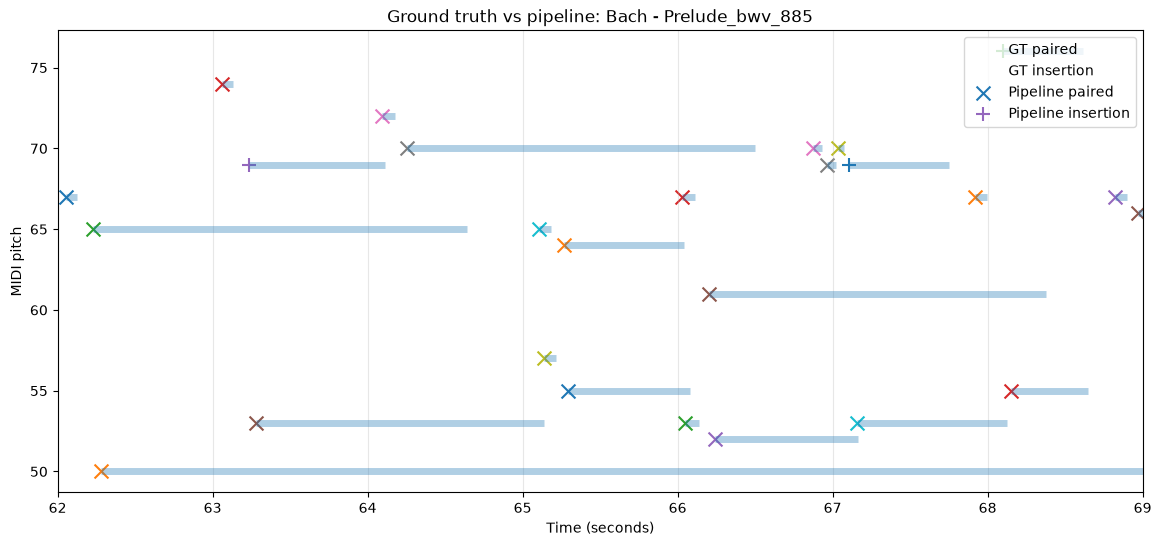

In [34]:
START_TIME = 62.0
END_TIME = 69.0

import matplotlib.pyplot as plt

response_notes = selected_sample["response"]["notes"]

segment_response_notes = [
    note for note in response_notes
    if START_TIME <= note["start"] <= END_TIME
]

segment_gt = [
    note for note in ground_truth
    if (
        note["onset"] is not None
        and START_TIME <= note["onset"] <= END_TIME
    )
]

segment_predictions = [
    note for note in predictions
    if (
        note["onset"] is not None
        and START_TIME <= note["onset"] <= END_TIME
    )
]


plt.figure(figsize=(14, 6))

# Draw the performed MIDI notes.
for note in segment_response_notes:
    plt.hlines(
        y=note["pitch"],
        xmin=note["start"],
        xmax=note["start"] + note["duration"],
        linewidth=5,
        alpha=0.35,
    )

# Ground-truth labels.
for note in segment_gt:
    if note["pitch"] is not None:
        marker = "o" if note["label"] == "paired" else "*"

        plt.scatter(
            note["onset"],
            note["pitch"],
            marker=marker,
            s=100,
            facecolors="none",
            label=f'GT {note["label"]}',
        )

# Pipeline labels.
for note in segment_predictions:
    if note["pitch"] is not None:
        marker = "x" if note["label"] == "paired" else "+"

        plt.scatter(
            note["onset"],
            note["pitch"],
            marker=marker,
            s=100,
            label=f'Pipeline {note["label"]}',
        )

plt.xlim(START_TIME, END_TIME)
plt.xlabel("Time (seconds)")
plt.ylabel("MIDI pitch")
plt.title(
    f'Ground truth vs pipeline: '
    f'{selected_result["composer"]} - {selected_result["title"]}'
)

# Remove duplicate legend entries.
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = {}

for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels[label] = handle

plt.legend(
    unique_labels.values(),
    unique_labels.keys(),
    loc="upper right",
)

plt.grid(axis="x", alpha=0.3)
plt.show()

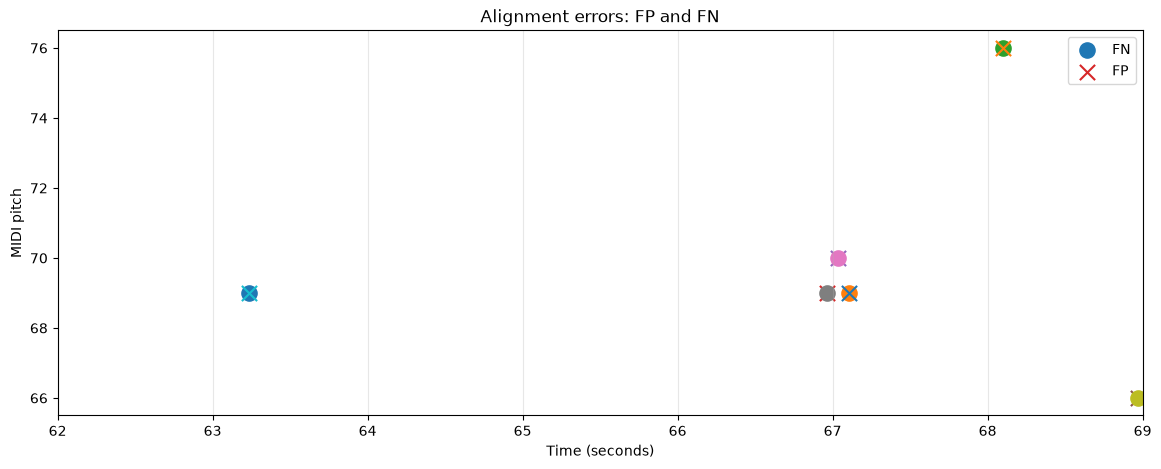

In [35]:
segment_error_df = error_df[
    (error_df["onset"] >= START_TIME)
    & (error_df["onset"] <= END_TIME)
]

plt.figure(figsize=(14, 5))

for _, row in segment_error_df.iterrows():
    if row["status"] == "FP":
        pitch = row["pipeline_pitch"]
        marker = "x"
    else:
        pitch = row["gt_pitch"]
        marker = "o"

    if pd.notna(pitch):
        plt.scatter(
            row["onset"],
            pitch,
            marker=marker,
            s=120,
            label=row["status"],
        )

plt.xlim(START_TIME, END_TIME)
plt.xlabel("Time (seconds)")
plt.ylabel("MIDI pitch")
plt.title("Alignment errors: FP and FN")

handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = {}

for handle, label in zip(handles, labels):
    if label not in unique_labels:
        unique_labels[label] = handle

plt.legend(
    unique_labels.values(),
    unique_labels.keys(),
)

plt.grid(axis="x", alpha=0.3)
plt.show()

In [36]:
segment_event_details = []

for event in selected_result["event_details"]:
    response_index = event.get("response_index")

    if response_index is None:
        continue

    response_event = selected_result[
        "response_events_normalized"
    ][response_index - 1]

    event_onset = (
        response_event["event_start"]
        + selected_result["response_onset_offset"]
    )

    if START_TIME <= event_onset <= END_TIME:
        segment_event_details.append({
            "onset": event_onset,
            "operation": event["operation_type"],
            "event_type": event["event_type"],
            "reference_index": event.get("reference_index"),
            "response_index": response_index,
            "correct_pitches": event.get("correct_pitches"),
            "missing_pitches": event.get("missing_pitches"),
            "extra_pitches": event.get("extra_pitches"),
        })

display(pd.DataFrame(segment_event_details))

,onset,operation,event_type,reference_index,response_index,correct_pitches,missing_pitches,extra_pitches
0,62.054546,match,note,146.0,153,None,None,None
1,62.230828,match,chord,147.0,154,"[50, 65]",[],[]
2,63.063094,match,note,148.0,155,None,None,None
3,63.231898,extra,note,NaN,156,None,None,None
4,63.282111,replacement,chord,149.0,157,[53],[69],[]
5,64.091941,match,note,150.0,158,None,None,None
6,64.256471,match,note,151.0,159,None,None,None
7,65.107968,match,chord,152.0,160,"[57, 65]",[],[]
8,65.265019,match,chord,153.0,161,"[55, 64]",[],[]
9,66.031046,match,chord,154.0,162,"[53, 67]",[],[]


Bach Prelude_bwv_858


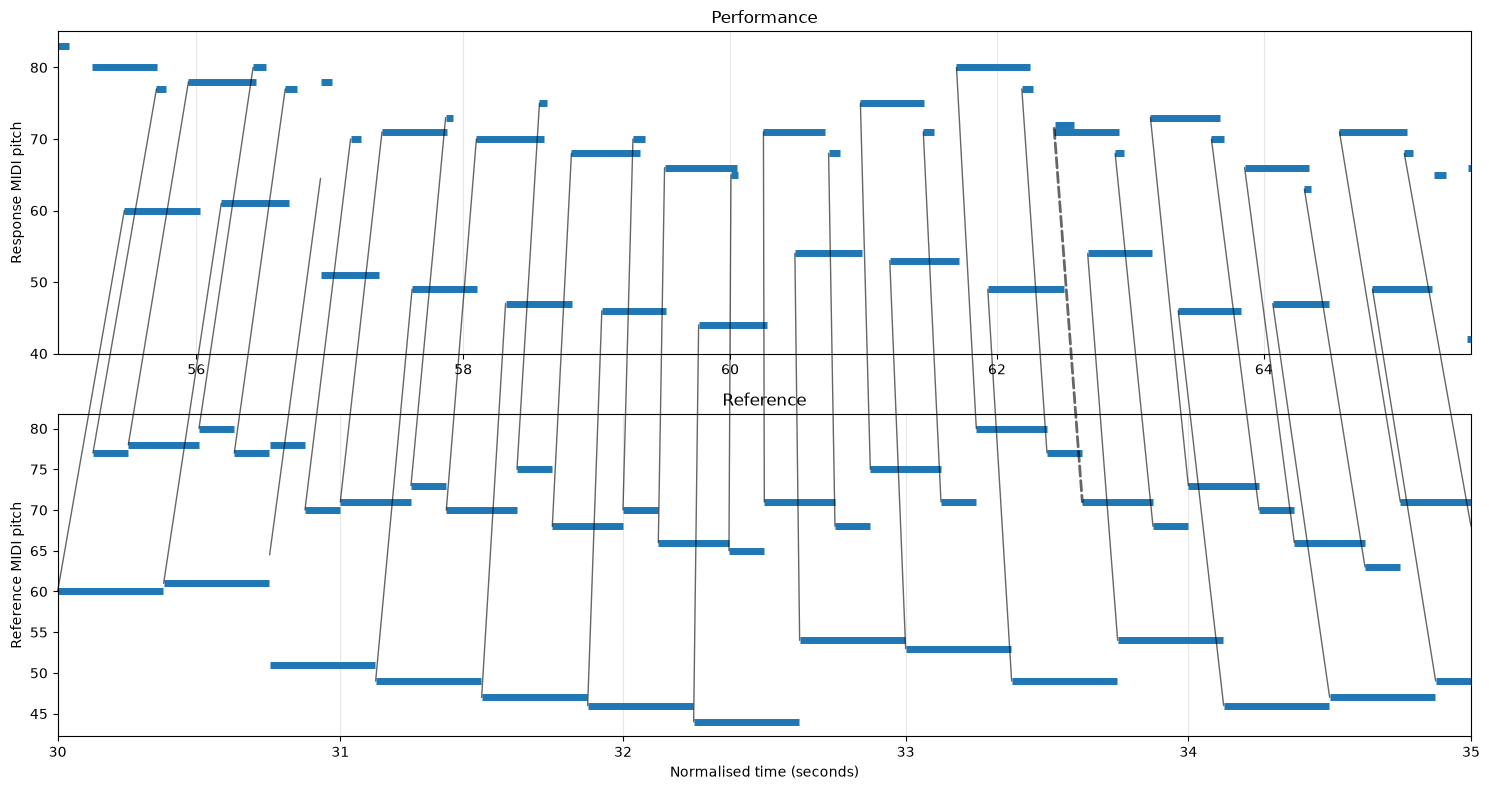

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch

SELECTED_SAMPLE_INDEX = 110 

selected_sample = samples[SELECTED_SAMPLE_INDEX]
selected_result = all_results[SELECTED_SAMPLE_INDEX]

ref_events = selected_result["ref_events_normalized"]
response_events = selected_result["response_events_normalized"]
event_details = selected_result["event_details"]

print(selected_result["composer"], selected_result["title"])

def plot_alignment(ref_events, response_events, event_details,
                   ref_start, ref_end):

    # Select operations whose reference event falls in the chosen segment.
    selected_details = []

    for detail in event_details:
        reference_index = detail.get("reference_index")

        if reference_index is None:
            continue

        ref_event = ref_events[reference_index - 1]
        ref_onset = ref_event["event_start"]

        if ref_start <= ref_onset <= ref_end:
            selected_details.append(detail)

    # Find the corresponding response time range.
    response_onsets = []

    for detail in selected_details:
        response_index = detail.get("response_index")

        if response_index is not None:
            response_event = response_events[response_index - 1]
            response_onsets.append(response_event["event_start"])

    if response_onsets:
        response_start = min(response_onsets) - 0.5
        response_end = max(response_onsets) + 0.5
    else:
        response_start = ref_start
        response_end = ref_end

    fig, (ax_response, ax_ref) = plt.subplots(
        2,
        1,
        figsize=(15, 8),
        height_ratios=[1, 1],
    )

    # ------------------------------
    # Top: response piano roll
    # ------------------------------
    for event in response_events:
        event_start = event["event_start"]

        if response_start <= event_start <= response_end:
            for note in event["notes"]:
                ax_response.hlines(
                    y=note["pitch"],
                    xmin=note["start"],
                    xmax=note["start"] + note["duration"],
                    linewidth=5,
                )

    ax_response.set_xlim(response_start, response_end)
    ax_response.set_ylabel("Response MIDI pitch")
    ax_response.set_title("Performance")

    # ------------------------------
    # Bottom: reference piano roll
    # ------------------------------
    for event in ref_events:
        event_start = event["event_start"]

        if ref_start <= event_start <= ref_end:
            for note in event["notes"]:
                ax_ref.hlines(
                    y=note["pitch"],
                    xmin=note["start"],
                    xmax=note["start"] + note["duration"],
                    linewidth=5,
                )

    ax_ref.set_xlim(ref_start, ref_end)
    ax_ref.set_xlabel("Normalised time (seconds)")
    ax_ref.set_ylabel("Reference MIDI pitch")
    ax_ref.set_title("Reference")

    # ------------------------------
    # Alignment lines
    # ------------------------------
    for detail in selected_details:
        operation = detail["operation_type"]

        reference_index = detail.get("reference_index")
        response_index = detail.get("response_index")

        if reference_index is None or response_index is None:
            continue

        ref_event = ref_events[reference_index - 1]
        response_event = response_events[response_index - 1]

        ref_x = ref_event["event_start"]
        response_x = response_event["event_start"]

        # Use the average pitch as the event centre.
        ref_y = sum(
            note["pitch"] for note in ref_event["notes"]
        ) / len(ref_event["notes"])

        response_y = sum(
            note["pitch"] for note in response_event["notes"]
        ) / len(response_event["notes"])

        if operation == "match":
            line_style = "-"
            line_width = 1.0
        else:
            line_style = "--"
            line_width = 2.0

        connector = ConnectionPatch(
            xyA=(response_x, response_y),
            coordsA=ax_response.transData,
            xyB=(ref_x, ref_y),
            coordsB=ax_ref.transData,
            linestyle=line_style,
            linewidth=line_width,
            alpha=0.6,
        )

        fig.add_artist(connector)

        # Mark missing and extra events.
    for detail in selected_details:
        operation = detail["operation_type"]

        if operation == "missing":
            reference_index = detail["reference_index"]
            ref_event = ref_events[reference_index - 1]

            ref_y = sum(
                note["pitch"] for note in ref_event["notes"]
            ) / len(ref_event["notes"])

            ax_ref.text(
                ref_event["event_start"],
                ref_y + 1,
                "missing",
                fontsize=8,
                rotation=45,
            )

        elif operation == "extra":
            response_index = detail["response_index"]
            response_event = response_events[response_index - 1]

            response_y = sum(
                note["pitch"] for note in response_event["notes"]
            ) / len(response_event["notes"])

            ax_response.text(
                response_event["event_start"],
                response_y + 1,
                "extra",
                fontsize=8,
                rotation=45,
            )
    
    ax_response.grid(axis="x", alpha=0.3)
    ax_ref.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_alignment(
    ref_events,
    response_events,
    event_details,
    ref_start=30.0,
    ref_end=35.0,
)

In [38]:
errors = comparison_df[
    comparison_df["status"] != "TP"
].copy()

error_categories = []

for index, error in errors.iterrows():
    category = "unmatched error"

    if error["status"] == "FP":
        opposite_status = "FN"
    else:
        opposite_status = "FP"

    possible_matches = errors[
        (errors["status"] == opposite_status)
        & (errors["label"] == error["label"])
    ]

    # For insertion, pitch must also agree.
    if error["label"] == "insertion":
        if error["status"] == "FP":
            pitch = error["pipeline_pitch"]
            possible_matches = possible_matches[
                possible_matches["gt_pitch"] == pitch
            ]
        else:
            pitch = error["gt_pitch"]
            possible_matches = possible_matches[
                possible_matches["pipeline_pitch"] == pitch
            ]

    nearest_difference = None

    for _, other_error in possible_matches.iterrows():
        difference = abs(error["onset"] - other_error["onset"])

        if nearest_difference is None or difference < nearest_difference:
            nearest_difference = difference

    if nearest_difference is not None:
        if (
            nearest_difference > ONSET_TOLERANCE
            and nearest_difference <= 0.15
        ):
            category = "onset tolerance boundary"

    error_categories.append(category)


errors["possible_cause"] = error_categories

display(errors.head(30))

,status,label,onset,gt_pitch,pipeline_pitch,onset_difference,possible_cause
19,FN,paired,10.433771,69.0,NaN,NaN,unmatched error
26,FN,paired,11.362190,70.0,NaN,NaN,unmatched error
50,FN,paired,20.750020,72.0,NaN,NaN,unmatched error
55,FN,paired,24.355792,72.0,NaN,NaN,unmatched error
74,FN,paired,28.185924,77.0,NaN,NaN,unmatched error
85,FN,paired,32.012851,75.0,NaN,NaN,unmatched error
100,FN,paired,40.498970,65.0,NaN,NaN,unmatched error
109,FN,paired,41.455168,67.0,NaN,NaN,unmatched error
117,FN,paired,44.126110,74.0,NaN,NaN,onset tolerance boundary
127,FN,paired,47.995772,74.0,NaN,NaN,unmatched error


In [39]:
for index, error in errors.iterrows():
    error_onset = error["onset"]

    near_chord = False

    for event in response_events:
        if event["event_type"] != "chord":
            continue

        difference = abs(
            event["event_start"]
            + selected_result["response_onset_offset"]
            - error_onset
        )

        if difference <= 0.10:
            near_chord = True
            break

    if near_chord:
        if errors.loc[index, "possible_cause"] == "unmatched error":
            errors.loc[index, "possible_cause"] = "chord context"
print(errors["possible_cause"].value_counts())

possible_cause
unmatched error             84
onset tolerance boundary    20
chord context               18
Name: count, dtype: int64


## Current limitation

Deletion matching is still count-based rather than identity-based. The ground-truth TSV identifies deleted score notes with `xml_id`, but the current pipeline output does not return that identifier, so we cannot yet confirm that a *specific* predicted deletion corresponds to a *specific* ground-truth deletion.

This version does fix an earlier bug where a missing (deleted) **chord** contributed 0 notes to the deletion count, because `event_details` leaves `correct_pitches`/`missing_pitches` as `None` for `missing`/`extra` events (this is true for both notes and chords, confirmed in `event_level_feedback()`). We now read the true note count for a missing chord directly from `ref_events` via `reference_index`, so the total deletion count is accurate again — only the note-to-note identity link is still missing.

A future improvement would be to keep the reference-note index or `xml_id` in each alignment result so that identity-based deletion matching becomes possible.